In [1]:
filepath = "/mnt/d/temp/user/ed/mart/mmplastic/Marine_Microplastics_WGS84_1130715472761438990.csv"

outcome_var_name = "measurement"

treatment_var = "intervention"

In [2]:
import numpy as np
import pandas as pd

from joblib import Parallel, delayed # for parallel processing
from patsy import dmatrix
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from toolz import partial
from pprint import pprint

# Data preparation

In [3]:
df = pd.read_csv(filepath)

In [4]:
df = df.dropna(subset=["Measurement"])

In [5]:
df['yyyymmdd'] = pd.to_datetime(df['Date'])
df['year'] = df['yyyymmdd'].dt.year
df['month'] = df['yyyymmdd'].dt.month
df['day'] = df['yyyymmdd'].dt.day

/tmp/ipykernel_384396/3844149097.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['yyyymmdd'] = pd.to_datetime(df['Date'])


In [6]:
df["measurement"] = np.where(df["Measurement"] > 1.0, 1.0, df["Measurement"])

In [7]:
# df["log_measurement"] = np.where(df["measurement"] > 0.0, np.log(df["measurement"]), -7.5)
df["log_measurement"] = np.log(df["measurement"])

/home/ed/miniconda3/envs/mypy311/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [8]:
# replace negative Inf to minimum value
min_outcome_var_over_neginf = np.min(df[outcome_var_name][df[outcome_var_name] != -np.inf])
df.loc[np.isneginf(df[outcome_var_name]), outcome_var_name] = min_outcome_var_over_neginf.item()

In [9]:
mean = df["measurement"].mean()
df["normed"] = (df["measurement"] - mean) / df["measurement"].std()

In [10]:
# m3_df.loc[:, ['Measurement', 'Oceans', 'Density Class', 'year']]

m3_df = df[
    (df['Unit'] == "pieces/m3") & (df["Oceans"].isin(['Atlantic Ocean', 'Pacific Ocean']))
].loc[:, ['measurement', 'Sampling Method', 'Density Class', 'year', 'Oceans']]
m3_df["intervention"] = (m3_df['Oceans'] == "Pacific Ocean").apply(lambda x: int(x))
# m3_df["intervention"] = (m3_df['Oceans'] == "Atlantic Ocean").apply(lambda x: int(x))
edf = m3_df.loc[:, ['measurement', 'intervention', 'Sampling Method', 'Density Class', 'year']]

In [11]:
edf["neuston_net"] = (edf["Sampling Method"] == "Neuston net").apply(lambda x: int(x))
edf = edf.rename(columns={"Sampling Method": "sampling_method", "Density Class": "density"})
df = edf.drop(columns=["sampling_method"])

In [12]:
df

,measurement,intervention,density,year,neuston_net
0,0.0180,0,Medium,2015,0
1,0.0000,1,Very Low,2002,1
2,0.0130,1,Medium,2006,0
3,1.0000,0,Very High,2018,0
4,0.0010,1,Low,2015,0
...,...,...,...,...,...
20418,0.0000,1,Very Low,2008,1
20419,0.0110,0,Medium,2015,0
20420,0.0216,0,Medium,2001,1
20421,0.0000,0,Very Low,2008,1


# Formula Definitions

In [ ]:
y2t = f"{outcome_var_name} ~ {treatment_var}"
covars = "C(density) + C(neuston_net) + year"
t2covars = f"{treatment_var} ~ {covars}"
y2covars = f"{outcome_var_name} ~ {treatment_var} + {covars}"

# Doubled Robustness Estimation

In [14]:

def bootstrap(data, est_fn, rounds=200, seed=123, pcts=[2.5, 97.5]):
    np.random.seed(seed)
    
    stats = Parallel(n_jobs=4)(
        delayed(est_fn)(data.sample(frac=1, replace=True))
        for _ in range(rounds)
    )
    
    return np.percentile(stats, pcts)

In [ ]:

def doubly_robust(df, formula, T, Y):
    # TODO(ed): check the returned type X as pandas.Dataframe, or add return_type='dataframe to dmatrix function
    X = dmatrix(formula, df)
    
    ps_model = LogisticRegression(penalty=None,
                                  max_iter=1000).fit(X, df[T])
    ps = ps_model.predict_proba(X)[:, 1]
    
    m0 = LinearRegression().fit(X[df[T]==0, :], df.query(f"{T}==0")[Y])
    m1 = LinearRegression().fit(X[df[T]==1, :], df.query(f"{T}==1")[Y])
    
    m0_hat = m0.predict(X)
    m1_hat = m1.predict(X)

    return (
        np.mean(df[T]*(df[Y] - m1_hat)/ps + m1_hat) -
        np.mean((1-df[T])*(df[Y] - m0_hat)/(1-ps) + m0_hat)
    )

In [16]:
formula = covars
T = treatment_var
Y = outcome_var_name

print("DR ATE:", doubly_robust(df, formula, T, Y))

est_fn = partial(doubly_robust, formula=formula, T=T, Y=Y)
print("95% CI", bootstrap(df, est_fn))

DR ATE: 0.04701801475978379
95% CI [0.03772139 0.05629967]


# Build Multi-tool agent design example

In [17]:
embedding_model_name = "gemma-2-embed"
lang_model_name = "tiger-gemma2"

max_tokens = 1024

In [18]:
import uuid

from abc import abstractmethod
from pydantic import BaseModel, Field
from typing import Annotated, Callable, List, Literal, Optional
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import AnyMessage, add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langchain_core.messages import (
    HumanMessage,
    ToolMessage
)
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import Runnable, RunnableConfig, RunnableLambda
from langchain_core.tools import tool

from langchain_ollama import ChatOllama
from langchain_openai import ChatOpenAI

## Build Graph Design

### Prompts

In [19]:
PROMPT_SPECIALIZED_ASSISTANT_ENTRY_NODE = f"""
"""
# content=f"The assistant is now the {assistant_name}. Reflect on the above conversation between the host assistant and the user."
# f" The user's intent is unsatisfied. Use the provided tools to assist the user. Remember, you are {assistant_name},"
# " and the booking, update, other other action is not complete until after you have successfully invoked the appropriate tool."
# " If the user changes their mind or needs help for other tasks, call the FallbackToMainAssistant function to let the primary host assistant take control."
# " Do not mention who you are - just act as the proxy for the assistant.",

### Assistant/Tool Constants

In [20]:
MAIN_ASSISTANT = "main_assistant"

SPECIALIZED_TOOLS = [
    "analyze_propensity_ate"
]

LEAVE_TOOL_NODE = "leave_tool"

### helper functions

In [21]:
def handle_tool_error(state) -> dict:
    error = state.get("error")
    tool_calls = state["messages"][-1].tool_calls
    return {
        "messages": [
            ToolMessage(
                content=f"Error: {repr(error)}\n please fix your mistakes.",
                tool_call_id=tc["id"],
            )
            for tc in tool_calls
        ]
    }


In [22]:
def _print_event(event: dict, _printed: set, max_length=1500):
    current_state = event.get("dialog_state")
    if current_state:
        print("Currently in: ", current_state[-1])
    message = event.get("messages")
    if message:
        if isinstance(message, list):
            message = message[-1]
        if message.id not in _printed:
            msg_repr = message.pretty_repr(html=True)
            if len(msg_repr) > max_length:
                msg_repr = msg_repr[:max_length] + " ... (truncated)"
            print(msg_repr)
            _printed.add(message.id)

### state definition

In [23]:
# node types: state node, action node

def update_dialog_stack(left: list[str], right: Optional[str]) -> list[str]:
    """Push or pop the state."""
    if right is None:
        return left
    if right == "pop":  # stack action node name, not real node
        return left[:-1]
    return left + [right]


class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    # user_info: str
    node_trajectory: Annotated[
        list[
            Literal[
                "main_assistant",
                "analyze_propensity_ate",
                # "update_flight",
                # "book_car_rental",
                # "book_hotel",
                # "book_excursion",
            ]
        ],
        update_dialog_stack,
    ]

### tools

In [ ]:
# Fallback Tool to main assistant
class FallbackToMainAssistant(BaseModel):
    """A tool to mark the current task as completed and/or to escalate control of the dialog to the main assistant,
    who can re-route the dialog based on the user's needs."""

    cancel: bool = True
    reason: str

    class Config:
        json_schema_extra = {
            "example": {
                "cancel": True,
                "reason": "User changed their mind about the current task.",
            },
            "example 2": {
                "cancel": True,
                "reason": "I have fully completed the task.",
            },
            "example 3": {
                "cancel": False,

                # ??
                "reason": "I need to search the user's emails or calendar for more information.",
            },
        }

In [24]:
@tool
def greeting():
    """
    Greeting to the users for causality tools.

    Returns:
        welcome message
    """
    greeting_message = """
    Welcome to the causality service for microplastics!
    """
    return greeting_message

In [25]:
class DoublyRobustEstimator:

    def __init__(self, formula, T, Y):
        self.formula = formula
        self.T = T
        self.Y = Y
    
    # def ATE(self, records: pd.DataFrame):
    #     ate_value = doubly_robust(records, self.formula, self.T, self.Y)
    #     return ate_value

    # def CI(self, records: pd.DataFrame):
    #     est_fn = partial(doubly_robust, formula=self.formula, T=self.T, Y=self.Y)
    #     return bootstrap(records, est_fn)

    # @staticmethod
    # @tool
    def calc_ATE(self, records: pd.DataFrame):
        # TODO read data from mart dynamically
        return doubly_robust(records, formula, T, Y)

In [27]:
from langchain_core.tools import StructuredTool

class DomainTool(BaseModel):
    name: str
    read_only_tools: List[StructuredTool]
    update_tools: List[StructuredTool]
    # read_only_tools: List[str]
    # update_tools: List[str]
    leave_tool_node_name: str

class DomainRouter:
    tool: DomainTool

    @abstractmethod
    def route(self, state: State) -> str:
        """
        Returns:
            node name
        """
        pass

### node build functions

In [28]:
def create_greeting_node_func(node_name: str) -> Callable:
    def greeting_node(state: State) -> dict:
        return {
            "messages": [
                ("ai", "Welcome to the causality service for microplastics!"),
            ]
        }
    return greeting_node

In [29]:
def create_entry_node_func(assistant_desc: str, new_node_name: str) -> Callable:
    def entry_node(state: State) -> dict:
        tool_call_id = state["messages"][-1].tool_calls[0]["id"]
        node = {
            "messages": [
                ToolMessage(
                    content=PROMPT_SPECIALIZED_ASSISTANT_ENTRY_NODE,
                    tool_call_id=tool_call_id
                )
            ],
            "node_trajectory": new_node_name
        }

        return node
    return entry_node

In [30]:
def create_tool_node_func(tools: list) -> dict:
    tool_node = ToolNode(tools).with_fallbacks(
        [
            RunnableLambda(
                handle_tool_error
            ),
        ],
        exception_key="error"
    )
    return tool_node

In [31]:
def create_pop_action_node_func(state: State) -> dict:
    messages = []
    if state["messages"][-1].tool_calls:
        messages.append(
            ToolMessage(
                content="Resuming dialog with the host assistant. Please reflect on the past conversation and assist the user as needed.",
                tool_call_id=state["messages"][-1].tool_calls[0]["id"]
            )
        )
    action_node = {
        "messages": messages,
        "node_trajectory": "pop",
    }
    return action_node

### node routing functions

In [32]:
def check_fallback(tool_calls: list) -> bool:
    fallback = any(tc["name"] == FallbackToMainAssistant.__name__ for tc in tool_calls)
    return fallback

def check_read_only_tools(tool_calls: list, tool_names: List[str]) -> bool:
    return all(tc["name"] in tool_names for tc in tool_calls)


In [33]:
# request, prompt, tool, router

# request: awaken request
# prompt: entry prompt
# tool: explicit tool implementation
# router: routing from tool assistant node to others

class PropensityATERequest(BaseModel):
    """
    Transfers work to a specialized assistant to handle microplastic data analysis
    """
    request: str = Field(
        description="Request to analyze microplastic data, for example average treatement effect via propensity score"
    )


propensity_ate_assistant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            f"""
            You are a specialized assistant for analyzing the average treatment effect using propensity score, especially doubly robust estimation.
            The main assistant delegates work to you whenever you need to analyze the average treatment effect for the data of microplastics.

            If you need more information or the customer changes their mind, fallback to the task back to the main assistant.
            Some examples for which you should {FallbackToMainAssistant.__name__}:
            - 'good-bye!'
            - 'bye bye'
            - 'bye'
            """
        ),
        ("placeholder", "{messages}")
    ]
)
propensity_ate_estimator = DoublyRobustEstimator(formula, T, Y)

# StructuredTool
@tool
def calc_propensity_ate():
    """
    Calculate the average treatement effect of microplastic
    """
    # TODO read data from mart dynamically
    return propensity_ate_estimator.calc_ATE(df)


propensity_ate_tool = DomainTool(
    name="analyze_propensity_ate",
    # TODO
    read_only_tools=[],
    update_tools=[calc_propensity_ate],
    leave_tool_node_name=LEAVE_TOOL_NODE
)


In [55]:
class PropensityAteRouter(DomainRouter):

    def __init__(self, tool: DomainTool):
        self.tool = tool

    def route(self, state: State) -> str:
        routed_node = tools_condition(state)
        if routed_node == END:
            return END

        tool_calls = state["messages"][-1].tool_calls

        check = check_fallback(tool_calls)
        if check:
            return self.tool.leave_tool_node_name 

        read_tool_check = check_read_only_tools(
            tool_calls=tool_calls,
            tool_names=[t.name for t in self.tool.read_only_tools]
        )
        if read_tool_check:
            return f"{self.tool.name}_read_only_tools"
        else:
            # return f"{self.tool.name}"
            # return f"calc_propensity_ate"
            return f"{self.tool.name}_update_tools"
        

propensity_ate_router = PropensityAteRouter(
    tool=propensity_ate_tool
)



In [ ]:
def route_from_main_assistant(state: State):
    node_routed = tools_condition(state)
    if node_routed == END:
        return END
    tool_calls = state["messages"][-1].tool_calls
    if tool_calls:
        first_tool_name = tool_calls[0]["name"]
        if first_tool_name == PropensityATERequest.__name__:
            return f"enter_analyze_propensity_ate"
        return f"{MAIN_ASSISTANT}_tools"
    
    raise ValueError("Invalid Route!")

In [ ]:
def route_from_greeting(state: State) -> Literal[
    "main_assistant",
    "analyze_propensity_ate"
]:
    nodes = state.get("node_trajectory")
    if not nodes:
        return MAIN_ASSISTANT
    return nodes[-1]

### model declaration

In [ ]:
# llm = ChatOllama(
#     model=lang_model_name,
#     temperature=0.8,
#     num_predict=max_tokens,
#     num_gpu=-1
# )

import os
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

### assistants

In [59]:
class Assistant:
    def __init__(self, runnable: Runnable):
        self.runnable = runnable

    def __call__(self, state: State, config: RunnableConfig):
        while True:
            result = self.runnable.invoke(state)

            if not result.tool_calls and (
                not result.content
                or isinstance(result.content, list)
                and not result.content[0].get("text")
            ):
                messages = state["messages"] + [("user", "Respond with a real output.")]
                state = {**state, "messages": messages}
            else:
                break
        node = {
            "messages": result
        }
        return node

In [60]:
propensity_ate_assistant_runnable = propensity_ate_assistant_prompt | llm.bind_tools(
    propensity_ate_tool.update_tools +
    [
        FallbackToMainAssistant
    ]
)

In [61]:
main_assistant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
            You are a helpful assistant for microplastics.
            Your primary role is to analyze for microplastic data to answer user queries.
            If a user requests to request the analysis microplastics,
            delegate the task to the appropriate specialized assistant by invoking the corresponding tool.
            The user is not aware of the different specialized assistants, so do not mention them; just quietly delegate through function calls.
            If a user request is not relevant to microplastic data analysis, give it up.
            """
        ),
        (
            "placeholder", "{messages}"
        )
    ]
)
# TODO
main_assistant_tools = [
]

main_assistant_runnable = main_assistant_prompt | llm.bind_tools(
    main_assistant_tools +
    [
        PropensityATERequest,
    ]
)

# define the graph

In [62]:
thread_id = str(uuid.uuid4())

sesion_config = {
    "configurable": {
        "thread_id": thread_id
    }
}

In [63]:
builder = StateGraph(State)

In [ ]:
builder.add_node("greeting", create_greeting_node_func(greeting))

builder.add_edge(START, "greeting")

builder.add_conditional_edges("greeting", route_from_greeting)
# builder.add_edge("greeting", MAIN_ASSISTANT)

In [ ]:
builder.add_node(
    "enter_analyze_propensity_ate",
    create_entry_node_func("Calculate ATE using propensity score", "analyze_propensity_ate")
)
builder.add_node("analyze_propensity_ate", Assistant(propensity_ate_assistant_runnable))

builder.add_edge("enter_analyze_propensity_ate", "analyze_propensity_ate")

domain_update_tool_node_name = f"{propensity_ate_tool.name}_update_tools"
builder.add_node(
    domain_update_tool_node_name,
    create_tool_node_func(propensity_ate_tool.update_tools)
    # "calc_propensity_ate",
    # create_tool_node_func([calc_propensity_ate])
)

builder.add_edge(
    domain_update_tool_node_name,
    # "calc_propensity_ate",
    "analyze_propensity_ate"
)

builder.add_conditional_edges(
    "analyze_propensity_ate",
    propensity_ate_router.route,
    [
        domain_update_tool_node_name,
        # "calc_propensity_ate",
        LEAVE_TOOL_NODE,
        END
    ]
)

In [ ]:
builder.add_node(MAIN_ASSISTANT, Assistant(main_assistant_runnable))
builder.add_node(
    f"{MAIN_ASSISTANT}_tools", create_tool_node_func(main_assistant_tools)
)

builder.add_conditional_edges(
    MAIN_ASSISTANT,
    route_from_main_assistant,
    [
        "enter_analyze_propensity_ate",
        f"{MAIN_ASSISTANT}_tools",
        END
    ],
)
builder.add_edge(f"{MAIN_ASSISTANT}_tools", MAIN_ASSISTANT)


In [67]:
builder.add_node(LEAVE_TOOL_NODE, create_pop_action_node_func)
builder.add_edge(LEAVE_TOOL_NODE, MAIN_ASSISTANT)

# compile graph

In [68]:
memory = MemorySaver()

graph = builder.compile(
    checkpointer=memory,
    interrupt_before=[
        # "calc_propensity_ate"
    ]
)

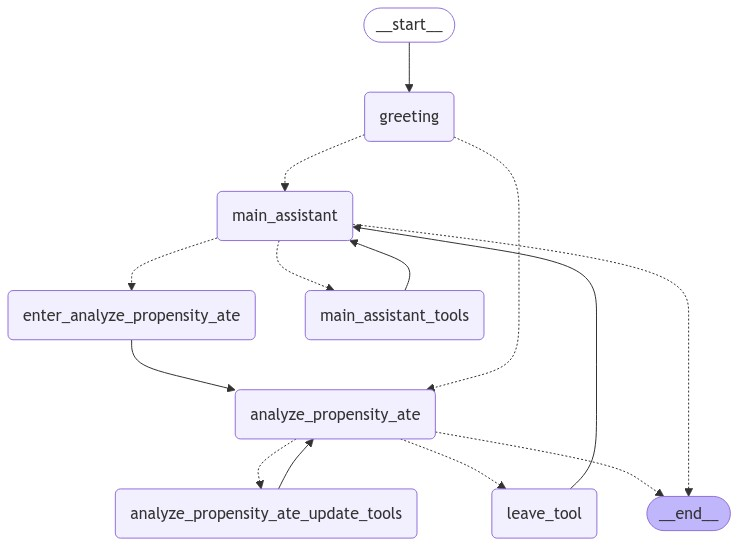

In [69]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

# test questions

In [70]:
tutorial_questions = [
    "Hi there, can I calculate ATE for microplastics?"
]

In [71]:
type(graph)

langgraph.graph.state.CompiledStateGraph

In [73]:
import uuid

thread_id = str(uuid.uuid4())

config = {
    "configurable": {
        # Checkpoints are accessed by thread_id
        "thread_id": thread_id,
    }
}

_printed = set()
# We can reuse the tutorial questions from part 1 to see how it does.
for question in tutorial_questions:
    events = graph.stream(
        input={
            "messages": [
                {"role":"user", "content":question}
            ]
        },
        # {"messages": ("user", question)}
        config=config, stream_mode="values"
    )
    for event in events:
        print(f"#### message: {event['messages'][-1]}")
        _print_event(event, _printed)
    snapshot = graph.get_state(config)
    while snapshot.next:
        # We have an interrupt! The agent is trying to use a tool, and the user can approve or deny it
        # Note: This code is all outside of your graph. Typically, you would stream the output to a UI.
        # Then, you would have the frontend trigger a new run via an API call when the user has provided input.
        try:
            user_input = input(
                "Do you approve of the above actions? Type 'y' to continue;"
                " otherwise, explain your requested changed.\n\n"
            )
        except:
            user_input = "y"
        if user_input.strip() == "y":
            # Just continue
            result = graph.invoke(
                None,
                config,
            )
        else:
            # Satisfy the tool invocation by
            # providing instructions on the requested changes / change of mind
            result = graph.invoke(
                {
                    "messages": [
                        ToolMessage(
                            tool_call_id=event["messages"][-1].tool_calls[0]["id"],
                            content=f"API call denied by user. Reasoning: '{user_input}'. Continue assisting, accounting for the user's input.",
                        )
                    ]
                },
                config,
            )
        snapshot = graph.get_state(config)

#### write.value {'messages': [{'role': 'user', 'content': 'Hi there, can I calculate ATE for microplastics?'}]}
#### message: content='Hi there, can I calculate ATE for microplastics?' additional_kwargs={} response_metadata={} id='9b687029-2f4f-4df8-a079-cf81f347e5e5'
================================ Human Message =================================

Hi there, can I calculate ATE for microplastics?
#### write.value greeting
#### ends: {'main_assistant': 'main_assistant', 'analyze_propensity_ate': 'analyze_propensity_ate'}
#### result: ['main_assistant']
#### write.value greeting
#### message: content='Welcome to the causality service for microplastics!' additional_kwargs={} response_metadata={} id='9e7d130b-5f89-4a03-808f-aa8d2e8d7c99'
================================== Ai Message ==================================

Welcome to the causality service for microplastics!
#### write.value main_assistant
#### ends: {'enter_analyze_propensity_ate': 'enter_analyze_propensity_ate', 'main_assista

In [74]:
pprint(event["messages"][-1].__dict__)

{'additional_kwargs': {'refusal': None},
 'content': 'The average treatment effect (ATE) for microplastics is '
            'approximately 0.047. If you have any further questions or need '
            'additional analysis, feel free to ask!',
 'example': False,
 'id': 'run-e0ecaa6c-f926-480c-8e74-4468f3ad4872-0',
 'invalid_tool_calls': [],
 'name': None,
 'response_metadata': {'finish_reason': 'stop',
                       'logprobs': None,
                       'model_name': 'gpt-4o-mini-2024-07-18',
                       'system_fingerprint': 'fp_e2bde53e6e',
                       'token_usage': {'completion_tokens': 35,
                                       'completion_tokens_details': {'audio_tokens': None,
                                                                     'reasoning_tokens': 0},
                                       'prompt_tokens': 307,
                                       'prompt_tokens_details': {'audio_tokens': None,
                                

In [ ]:
# import uuid

# thread_id = str(uuid.uuid4())

# config = {
#     "configurable": {
#         # Checkpoints are accessed by thread_id
#         "thread_id": thread_id,
#     }
# }

# response = graph.invoke(
#     input={
#         "messages": [
#             ("user", tutorial_questions[0])
#         ]
#     },
#     config=config
# )

# from pprint import pprint
# pprint(response)